In [1]:
import sys
import warnings
from pathlib import Path

PROJECT_ROOT = Path(r"C:\Users\dunca\OneDrive\Documents\UON\SCS6104\Capstone")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

warnings.filterwarnings("ignore", category=FutureWarning)

import logging
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(message)s", datefmt="%H:%M:%S")

import numpy as np
import pandas as pd

from src.ml.data import get_train_val_test_splits
from src.ml.anomaly import (
    train_on_benign, score_anomaly,
    evaluate_separability, detection_rate_at_threshold, save_model,
)

splits = get_train_val_test_splits(sample_per_family=25_000)

X_train = splits["X_train"]
X_val   = splits["X_val"]
X_test  = splits["X_test"]
y_train = splits["y_train"]["attack_family_denorm"]
y_val   = splits["y_val"]["attack_family_denorm"]
y_test  = splits["y_test"]["attack_family_denorm"]

print(f"Training set: {X_train.shape}")
print(f"  Benign: {(y_train == 'Benign').sum():,}")
print(f"  Attack: {(y_train != 'Benign').sum():,}")

21:04:46 | Loading labeled events (≤25000/family)
21:05:50 | Loaded 118,028 labeled rows
21:05:50 | Class distribution: {'Benign': 25000, 'DoS': 25000, 'DDoS': 25000, 'Reconnaissance': 25000, 'Brute Force': 13835, 'Web Attack': 2180, 'Botnet': 1966, 'Infiltration': 36, 'Exploit': 11}
21:05:52 | Splits: train=82,619, val=11,803, test=23,606


Training set: (82619, 76)
  Benign: 17,500
  Attack: 65,119


In [2]:
model = train_on_benign(X_train, y_train, contamination=0.05)
print(f"\n✅ Model trained")

21:13:16 | Training Isolation Forest on 17,500 benign rows
21:13:16 |   Contamination: 0.05 (lower = stricter)
21:13:17 |   Trained in 0.8s



✅ Model trained


In [3]:
scores = score_anomaly(model, X_val)

print("=== ANOMALY SCORE DISTRIBUTION BY CLASS (Validation) ===")
separability = evaluate_separability(scores, y_val)
print(separability)

=== ANOMALY SCORE DISTRIBUTION BY CLASS (Validation) ===
                count    mean  median     std     min     max
attack_family                                                
Benign           2500  0.1357  0.0545  0.1808  0.0000  0.9887
Botnet            196  0.0862  0.0608  0.1118  0.0504  0.8124
Brute Force      1384  0.1632  0.1659  0.0858  0.0310  0.3536
DDoS             2500  0.4232  0.4923  0.2627  0.0200  1.0000
DoS              2500  0.5718  0.8173  0.3568  0.0176  0.9680
Exploit             1  0.9854  0.9854     NaN  0.9854  0.9854
Infiltration        4  0.7768  0.7639  0.1070  0.6599  0.9195
Reconnaissance   2500  0.0663  0.0680  0.0242  0.0379  0.5937
Web Attack        218  0.1601  0.1432  0.0980  0.0217  0.6899


In [4]:
print("=== DETECTION RATE AT THRESHOLD = 0.5 (Validation) ===\n")
detection = detection_rate_at_threshold(scores, y_val, threshold=0.5)
print(detection.to_string(index=False))

=== DETECTION RATE AT THRESHOLD = 0.5 (Validation) ===

         class  n_total  n_flagged  detection_rate_pct
  Infiltration        4          4              100.00
       Exploit        1          1              100.00
           DoS     2500       1600               64.00
          DDoS     2500       1127               45.08
        Benign     2500        170                6.80
    Web Attack      218          7                3.21
        Botnet      196          5                2.55
Reconnaissance     2500          2                0.08
   Brute Force     1384          0                0.00


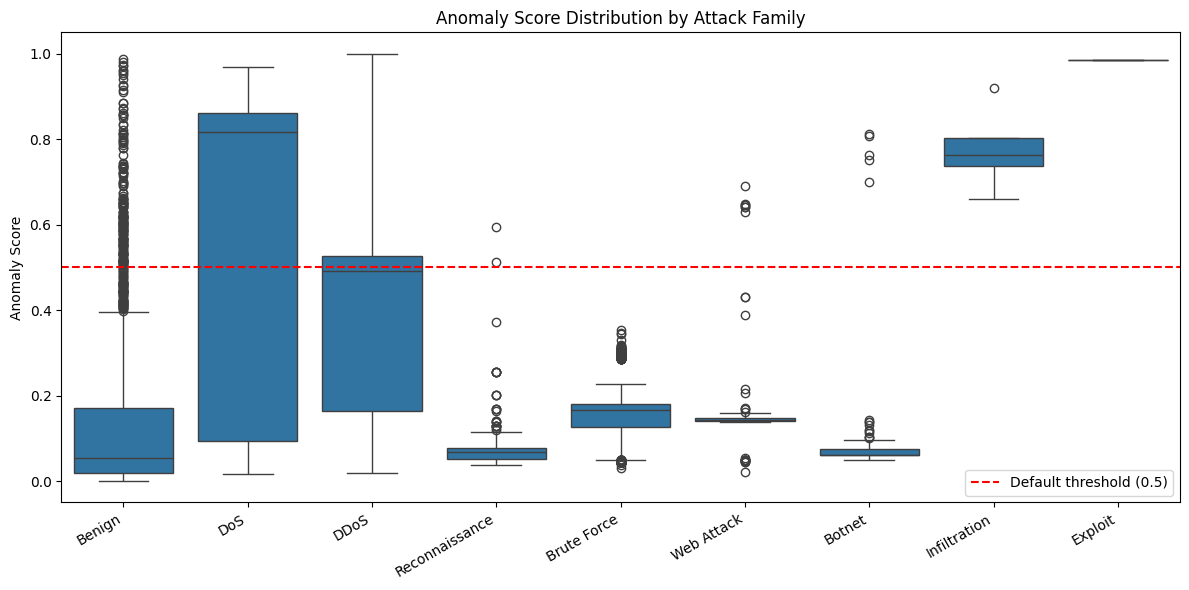

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Build a long-format dataframe for plotting
plot_df = pd.DataFrame({
    "Anomaly Score": scores,
    "Class": y_val.values,
})

# Boxplot by class
fig, ax = plt.subplots(figsize=(12, 6))
order = ["Benign", "DoS", "DDoS", "Reconnaissance", "Brute Force",
         "Web Attack", "Botnet", "Infiltration", "Exploit"]
order = [c for c in order if c in plot_df["Class"].unique()]
sns.boxplot(data=plot_df, x="Class", y="Anomaly Score", ax=ax, order=order)
ax.axhline(y=0.5, color="red", linestyle="--", label="Default threshold (0.5)")
ax.set_title("Anomaly Score Distribution by Attack Family")
ax.set_xlabel("")
ax.legend()
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [6]:
print("=== ANOMALY SCORE DRILL-DOWN: TINY CLASSES ===\n")

for cls in ["Infiltration", "Exploit"]:
    mask = y_val == cls
    if mask.sum() == 0:
        print(f"{cls}: not in validation set, skipping")
        continue

    cls_scores = scores[mask]
    print(f"{cls} (n={mask.sum()}):")
    print(f"  Mean score:    {cls_scores.mean():.4f}")
    print(f"  Max score:     {cls_scores.max():.4f}")
    print(f"  Min score:     {cls_scores.min():.4f}")
    print(f"  Flagged @ 0.5: {(cls_scores >= 0.5).sum()}/{mask.sum()}")
    print()

=== ANOMALY SCORE DRILL-DOWN: TINY CLASSES ===

Infiltration (n=4):
  Mean score:    0.7768
  Max score:     0.9195
  Min score:     0.6599
  Flagged @ 0.5: 4/4

Exploit (n=1):
  Mean score:    0.9854
  Max score:     0.9854
  Min score:     0.9854
  Flagged @ 0.5: 1/1



In [7]:
test_scores = score_anomaly(model, X_test)

print("=== TEST SET — ANOMALY SCORE BY CLASS ===")
print(evaluate_separability(test_scores, y_test))

print("\n=== TEST SET — DETECTION RATES ===")
print(detection_rate_at_threshold(test_scores, y_test, threshold=0.5).to_string(index=False))

=== TEST SET — ANOMALY SCORE BY CLASS ===
                count    mean  median     std     min     max
attack_family                                                
Benign           5000  0.1265  0.0538  0.1634  0.0000  1.0000
Botnet            394  0.0763  0.0562  0.0891  0.0185  0.7618
Brute Force      2767  0.1531  0.1583  0.0799  0.0286  0.3301
DDoS             5000  0.4074  0.4608  0.2453  0.0214  0.9282
DoS              5000  0.5285  0.7519  0.3278  0.0162  0.8934
Exploit             2  0.9623  0.9623  0.0045  0.9592  0.9655
Infiltration        7  0.4617  0.6659  0.3748  0.0182  0.9051
Reconnaissance   5000  0.0620  0.0629  0.0287  0.0351  0.7331
Web Attack        436  0.1465  0.1326  0.0980  0.0410  0.7237

=== TEST SET — DETECTION RATES ===
         class  n_total  n_flagged  detection_rate_pct
       Exploit        2          2              100.00
           DoS     5000       3030               60.60
  Infiltration        7          4               57.14
          DDoS     5

In [8]:
metadata = {
    "model_type": "IsolationForest",
    "training_approach": "benign_only",
    "n_estimators": 200,
    "contamination": 0.05,
    "training_set_size": (y_train == "Benign").sum(),
    "score_normalization": "min_max_to_0_1",
    "feature_count": X_train.shape[1],
}

path = save_model(model, name="iforest_v1", metadata=metadata)
print(f"\n✅ Saved to: {path}")
print(f"   Size: {path.stat().st_size / 1e6:.2f} MB")

21:14:31 | Model saved: C:\Users\dunca\OneDrive\Documents\UON\SCS6104\Capstone\models\iforest_v1.joblib



✅ Saved to: C:\Users\dunca\OneDrive\Documents\UON\SCS6104\Capstone\models\iforest_v1.joblib
   Size: 1.47 MB
